In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
np.random.binomial(1, 0.1)

0

In [ ]:
def sample_offsping(nb_individuals, l):
    nb_offspring = np.random.poisson(l, size=nb_individuals)
    return nb_offspring.sum()

def sample_offsping_highvar(nb_individuals, l0, l1):
    res = np.random.binomial(1, 0.1)
    if res == 1: nb_offspring = np.random.poisson(l0, size=nb_individuals)
    else:nb_offspring = np.random.poisson(l1, size=nb_individuals)
    return nb_offspring.sum()



In [ ]:
N = 10000
mu = 1e-2

In [ ]:
offspring_distributions = []

for offspring_expectation in [2, 10]:
    type_A_offspring_distrib = []
    for i in tqdm(range(2000)):
        type_A_individuals = np.random.binomial(N, mu)
        type_A_offspring = sample_offsping(type_A_individuals, l=offspring_expectation)
        type_a_offspring = sample_offsping(N - type_A_individuals, l=offspring_expectation)
        type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
        type_A_offspring_distrib.append(type_A_offspring_next_generation)

    offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
    offspring_distribution["model"] = "lambda=" + str(offspring_expectation)
    offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
A = offspring_distributions

100%|██████████████████████████████████████| 2000/2000 [00:02<00:00, 685.87it/s]


In [ ]:

def sample_offsping(nb_individuals, alpha, p0=0):
    if p0 == 1:
        return 0
    random_uni = np.random.uniform(0, 1, nb_individuals)
    nb_offspring = (np.exp(1/alpha * np.log((1-p0)/random_uni)))
    return nb_offspring.sum()

In [ ]:
offspring_distributions = []

for alpha in [1.9,1.7, 1.5, 1.3]:
    type_A_offspring_distrib = []
    for i in tqdm(range(5000)):
        type_A_individuals = np.random.binomial(N, mu)
        type_A_offspring = sample_offsping(type_A_individuals, alpha=alpha)
        type_a_offspring = sample_offsping(N - type_A_individuals,  alpha=alpha)
        type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
        type_A_offspring_distrib.append(type_A_offspring_next_generation)

    offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
    offspring_distribution["model"] = "alpha=" + str(alpha)
    offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
A = offspring_distributions

100%|█████████████████████████████████████| 5000/5000 [00:01<00:00, 2500.99it/s]


(-100.0, 1000.0)

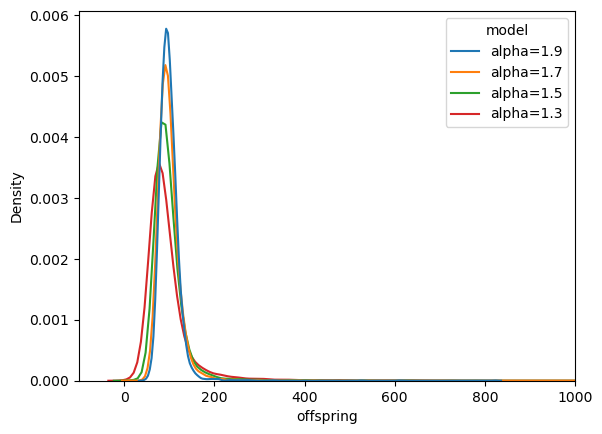

In [ ]:
fig, ax = plt.subplots(1)
sns.kdeplot(data=A,x="offspring", hue="model", ax=ax)
ax.set_xlim(-100, 1000)

In [ ]:
offspring_distributions = []

type_A_offspring_distrib = []
for i in tqdm(range(2000)):
    type_A_individuals = np.random.binomial(N, mu)
    type_A_offspring = sample_offsping_highvar(type_A_individuals, l0=100, l1=20)
    type_a_offspring = sample_offsping_highvar(N - type_A_individuals, l0=100, l1=20)
    type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
    type_A_offspring_distrib.append(type_A_offspring_next_generation)

offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
offspring_distribution["model"] = "high_var" 
offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
B = offspring_distributions

100%|██████████████████████████████████████| 2000/2000 [00:02<00:00, 816.26it/s]


<AxesSubplot:xlabel='offspring', ylabel='Density'>

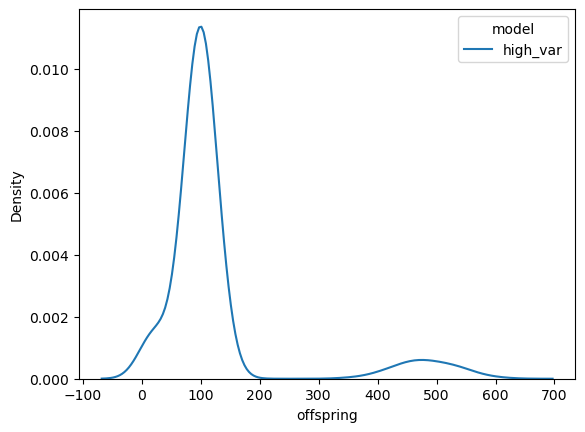

In [ ]:
sns.kdeplot(data=B,x="offspring", hue="model")

In [ ]:
AB = pd.concat([A, B])

<AxesSubplot:xlabel='offspring', ylabel='Density'>

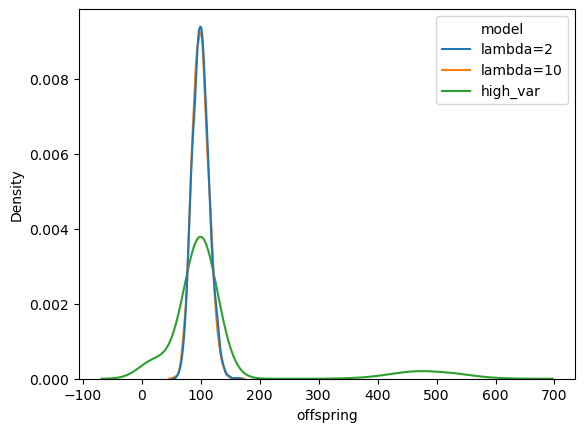

In [ ]:
sns.kdeplot(data=AB,x="offspring", hue="model")


In [ ]:
#
#type_A_individuals = np.random.binomial(N, mu)
#typenp.random.choice(np.arange(0, N), size=type_A_individuals, replace=False)

In [ ]:
offspring_expectation = 10

In [ ]:
offspring_distributions = []

for offspring_expectation in [2, 10]:
    type_A_offspring_distrib = []
    for _ in tqdm(range(2000)):
        offsprings_per_population = np.zeros(N)
        for i in range(N): offsprings_per_population[i] = sample_offsping(1, l=offspring_expectation)
        type_A_offspring = 0
        type_a_offspring = 0
        for i in range(N):
            offsprings_per_individuals =  offsprings_per_population[i]
            type_A_individual = np.random.binomial(offsprings_per_population[i], mu)
            type_a_individual = offsprings_per_individuals - type_A_individual
            type_A_offspring += type_A_individual
            type_a_offspring += type_a_individual
        type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
        type_A_offspring_distrib.append(type_A_offspring_next_generation)
    offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
    offspring_distribution["model"] = "lambda=" + str(offspring_expectation)
    offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
C = offspring_distributions

100%|███████████████████████████████████████| 2000/2000 [04:13<00:00,  7.90it/s]


In [ ]:
offspring_distributions = []

type_A_offspring_distrib = []
for _ in tqdm(range(2000)):
    offsprings_per_population = np.zeros(N)
    for i in range(N): offsprings_per_population[i] = sample_offsping_highvar(1, l0=100, l1=20)
    type_A_offspring = 0
    type_a_offspring = 0
    for i in range(N):
        offsprings_per_individuals =  offsprings_per_population[i]
        type_A_individual = np.random.binomial(offsprings_per_population[i], mu)
        type_a_individual = offsprings_per_individuals - type_A_individual
        type_A_offspring += type_A_individual
        type_a_offspring += type_a_individual
    type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
    type_A_offspring_distrib.append(type_A_offspring_next_generation)

offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
offspring_distribution["model"] = "high_var"
offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
D = offspring_distributions

100%|███████████████████████████████████████| 2000/2000 [04:40<00:00,  7.13it/s]


In [ ]:
offspring_distributions = []

for alpha in [1.9, 1.7, 1.5, 1.3]:
    type_A_offspring_distrib = []
    for _ in tqdm(range(5000)):
        offsprings_per_population = np.zeros(N)
        for i in range(N): offsprings_per_population[i] = sample_offsping(1, alpha=alpha)
        type_A_offspring = 0
        type_a_offspring = 0
        for i in range(N):
            offsprings_per_individuals =  offsprings_per_population[i]
            type_A_individual = np.random.binomial(offsprings_per_population[i], mu)
            type_a_individual = offsprings_per_individuals - type_A_individual
            type_A_offspring += type_A_individual
            type_a_offspring += type_a_individual
        type_A_offspring_next_generation = np.random.hypergeometric(type_A_offspring, type_a_offspring, N)
        type_A_offspring_distrib.append(type_A_offspring_next_generation)
    offspring_distribution = pd.DataFrame(type_A_offspring_distrib, columns=["offspring"])
    offspring_distribution["model"] = "alpha=" + str(alpha)
    offspring_distributions.append(offspring_distribution)
offspring_distributions = pd.concat(offspring_distributions)
C = offspring_distributions

100%|███████████████████████████████████████| 5000/5000 [17:13<00:00,  4.84it/s]


In [ ]:
C = pd.read_csv("../C.csv")

(-100.0, 500.0)

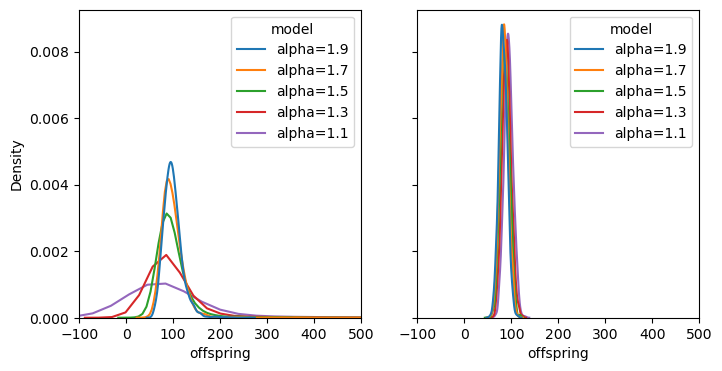

In [ ]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))

sns.kdeplot(data=A,x="offspring", hue="model", ax=axs[0])
sns.kdeplot(data=C,x="offspring", hue="model", ax=axs[1])

axs[0].set_xlim(-100, 500)

In [ ]:
C = pd.read_csv("C")

FileNotFoundError: [Errno 2] No such file or directory: 'C'

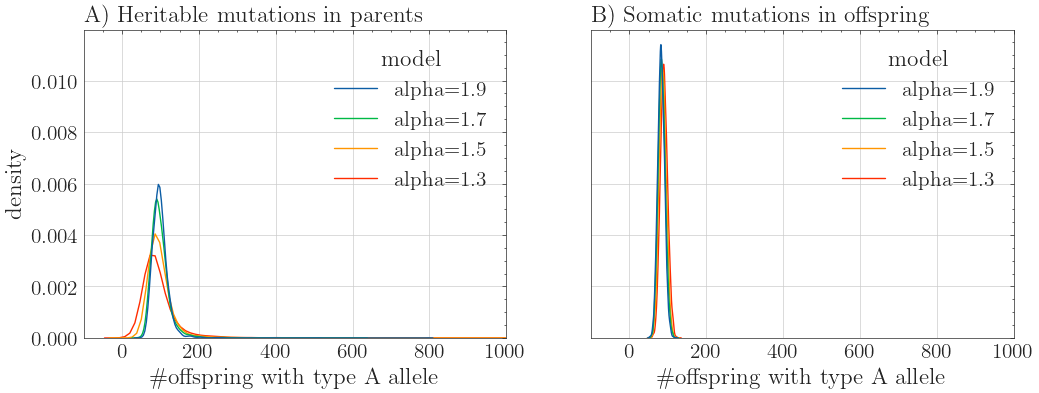

In [ ]:
sns.set(font_scale=1.4)
sns.set_style("white")
plt.style.use('science')

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(12, 4))

sns.kdeplot(data=A,x="offspring", hue="model", ax=axs[0]).set_title("a) Heritable mutations in parents", loc="left")
sns.kdeplot(data=C,x="offspring", hue="model", ax=axs[1]).set_title("b) Somatic mutations in offspring", loc="left")

axs[0].set_xlim(-100, 1000)

axs[0].grid(True)
axs[1].grid(True)
axs[0].set(xlabel=r"\#offspring with type A allele", ylabel="density")
axs[1].set(xlabel=r"\#offspring with type A allele", ylabel="density")



plt.savefig("Figure_0.pdf", dpi=600)

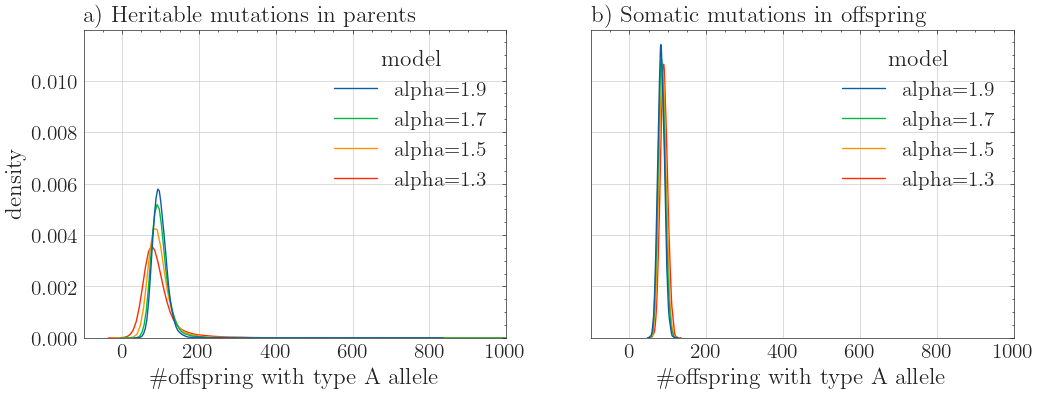

In [ ]:
sns.set(font_scale=1.4)
sns.set_style("white")
plt.style.use('science')

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(12, 4))

sns.kdeplot(data=A,x="offspring", hue="model", ax=axs[0]).set_title("a) Heritable mutations in parents", loc="left")
sns.kdeplot(data=C,x="offspring", hue="model", ax=axs[1]).set_title("b) Somatic mutations in offspring", loc="left")

axs[0].set_xlim(-100, 1000)

axs[0].grid(True)
axs[1].grid(True)
axs[0].set(xlabel=r"\#offspring with type A allele", ylabel="density")
axs[1].set(xlabel=r"\#offspring with type A allele", ylabel="density")


plt.savefig("Figure_01.pdf", dpi=600)

[Text(0.5, 0, '\\#offspring with type A allele'), Text(0, 0.5, '')]

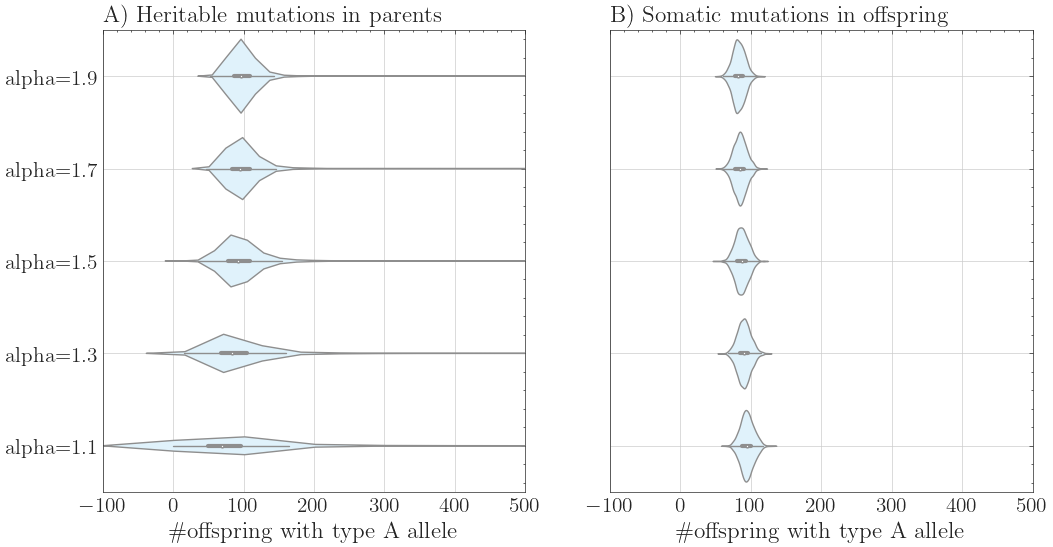

In [ ]:
sns.set(font_scale=1.4)
sns.set_style("white")
plt.style.use('science')

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(12, 6))

sns.violinplot(data=A, x="offspring", y="model", ax=axs[0], color="#dcf3ff").set_title("A) Heritable mutations in parents", loc="left")
sns.violinplot(data=C, x="offspring", y="model", ax=axs[1], color="#dcf3ff").set_title("B) Somatic mutations in offspring", loc="left")

axs[0].set_xlim(-100, 500)

axs[0].grid(True)
axs[1].grid(True)
axs[0].set(xlabel=r"\#offspring with type A allele", ylabel="")
axs[1].set(xlabel=r"\#offspring with type A allele", ylabel="")

In [ ]:
CD = pd.concat([C, D])

<AxesSubplot:xlabel='offspring', ylabel='Density'>

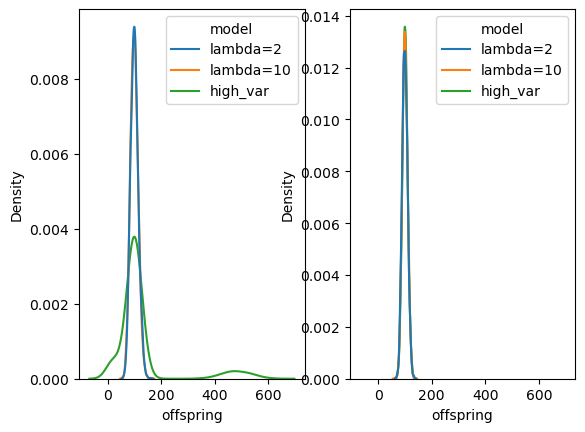

In [ ]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)

sns.kdeplot(data=AB,x="offspring", hue="model", ax=axs[0])

sns.kdeplot(data=CD,x="offspring", hue="model", ax=axs[1])
